# 01 — Exploratory Data Analysis

Project: Home Credit Default Risk / Credit Risk Scoring Service

Цель ноутбука:

- понять структуру исходных данных;
- проверить распределение таргета;
- найти пропуски;
- изучить числовые и категориальные признаки;
- посмотреть признаки, связанные с дефолтом;
- подготовить идеи для feature engineering.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(RAW_DATA_DIR)

/Users/artem/PycharmProjects/credit-risk-scoring-service
/Users/artem/PycharmProjects/credit-risk-scoring-service/data/raw


In [5]:
application_train = pd.read_csv(RAW_DATA_DIR / "application_train.csv")
application_test = pd.read_csv(RAW_DATA_DIR / "application_test.csv")

In [6]:
application_train.shape, application_test.shape

((307511, 122), (48744, 121))

In [7]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [8]:
application_train.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [9]:
application_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


## 2. Target distribution

Проверим распределение целевой переменной `TARGET`.

В датасете Home Credit:

- `TARGET = 0` — клиент вернул кредит без серьёзных проблем;
- `TARGET = 1` — у клиента были проблемы с выплатой кредита.

In [10]:
target_counts = application_train["TARGET"].value_counts()
target_share = application_train["TARGET"].value_counts(normalize=True)

target_distribution = pd.DataFrame(
    {
        "count": target_counts,
        "share": target_share,
    }
)

target_distribution

,count,share
TARGET,,
0,282686,0.919271
1,24825,0.080729


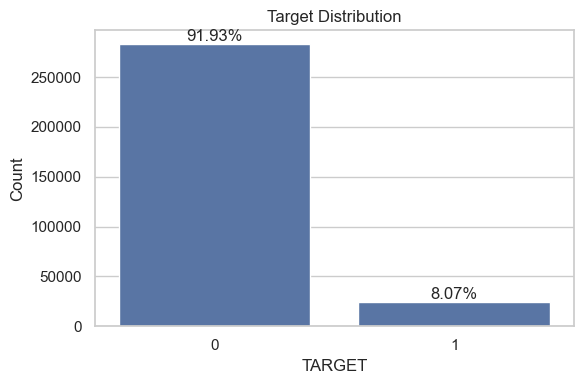

In [12]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=application_train, x="TARGET")

plt.title("Target Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")

for p in ax.patches:
    count = int(p.get_height())
    share = count / len(application_train)

    ax.annotate(
        f"{share:.2%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Target distribution conclusions

Целевая переменная сильно несбалансирована:

- класс `0` занимает примерно 92%;
- класс `1` занимает примерно 8%.

Это значит, что в задаче кредитного скоринга нельзя полагаться только на accuracy.

Для оценки моделей лучше использовать:

- ROC-AUC;
- PR-AUC;
- precision;
- recall;
- F1-score;
- KS statistic;
- default rate by score bands.

## 3. Data types and missing values

Теперь посмотрим:

- какие типы данных есть в `application_train`;
- сколько числовых и категориальных признаков;
- в каких колонках больше всего пропусков.

Это важно, потому что дальше для разных типов признаков будут разные способы обработки.

In [13]:
application_train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [14]:
numeric_features = application_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = application_train.select_dtypes(include=["object", "string"]).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 106
Categorical features: 16


In [15]:
categorical_features

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [16]:
categorical_summary = pd.DataFrame(
    {
        "n_unique": application_train[categorical_features].nunique(),
        "missing_count": application_train[categorical_features].isna().sum(),
        "missing_rate": application_train[categorical_features].isna().mean(),
    }
).sort_values("missing_rate", ascending=False)

categorical_summary

,n_unique,missing_count,missing_rate
FONDKAPREMONT_MODE,4,210295,0.683862
WALLSMATERIAL_MODE,7,156341,0.508408
HOUSETYPE_MODE,3,154297,0.501761
EMERGENCYSTATE_MODE,2,145755,0.473983
OCCUPATION_TYPE,18,96391,0.313455
NAME_TYPE_SUITE,7,1292,0.004201
NAME_CONTRACT_TYPE,2,0,0.000000
CODE_GENDER,3,0,0.000000
FLAG_OWN_CAR,2,0,0.000000
FLAG_OWN_REALTY,2,0,0.000000


### Categorical features observations

В `application_train` найдено 16 категориальных признаков.

Наибольшая доля пропусков наблюдается у признаков, связанных с характеристиками жилья:

- `FONDKAPREMONT_MODE`;
- `WALLSMATERIAL_MODE`;
- `HOUSETYPE_MODE`;
- `EMERGENCYSTATE_MODE`.

Также заметная доля пропусков есть у признака `OCCUPATION_TYPE`.

На этапе feature engineering такие пропуски не стоит автоматически удалять. Возможные варианты обработки:

- заполнить значением `Unknown`;
- создать отдельный missing-indicator;
- оставить пропуски для моделей, которые умеют с ними работать;
- обработать как отдельную категорию при WOE-биннинге.

## 4. Missing values

Посмотрим долю пропусков по всем признакам.

Пропуски важны, потому что:

- они могут означать отсутствие информации о клиенте;
- в кредитном скоринге сам факт отсутствия информации может быть связан с риском;
- разные модели по-разному работают с пропусками.

In [17]:
missing_values = (
    application_train
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "feature"})
)

missing_values["missing_count"] = (
    application_train[missing_values["feature"]]
    .isna()
    .sum()
    .values
)

missing_values.head(30)

,feature,missing_rate,missing_count
0,COMMONAREA_MEDI,0.698723,214865
1,COMMONAREA_AVG,0.698723,214865
2,COMMONAREA_MODE,0.698723,214865
3,NONLIVINGAPARTMENTS_MODE,0.694330,213514
4,NONLIVINGAPARTMENTS_AVG,0.694330,213514
5,NONLIVINGAPARTMENTS_MEDI,0.694330,213514
6,FONDKAPREMONT_MODE,0.683862,210295
7,LIVINGAPARTMENTS_MODE,0.683550,210199
8,LIVINGAPARTMENTS_AVG,0.683550,210199
9,LIVINGAPARTMENTS_MEDI,0.683550,210199


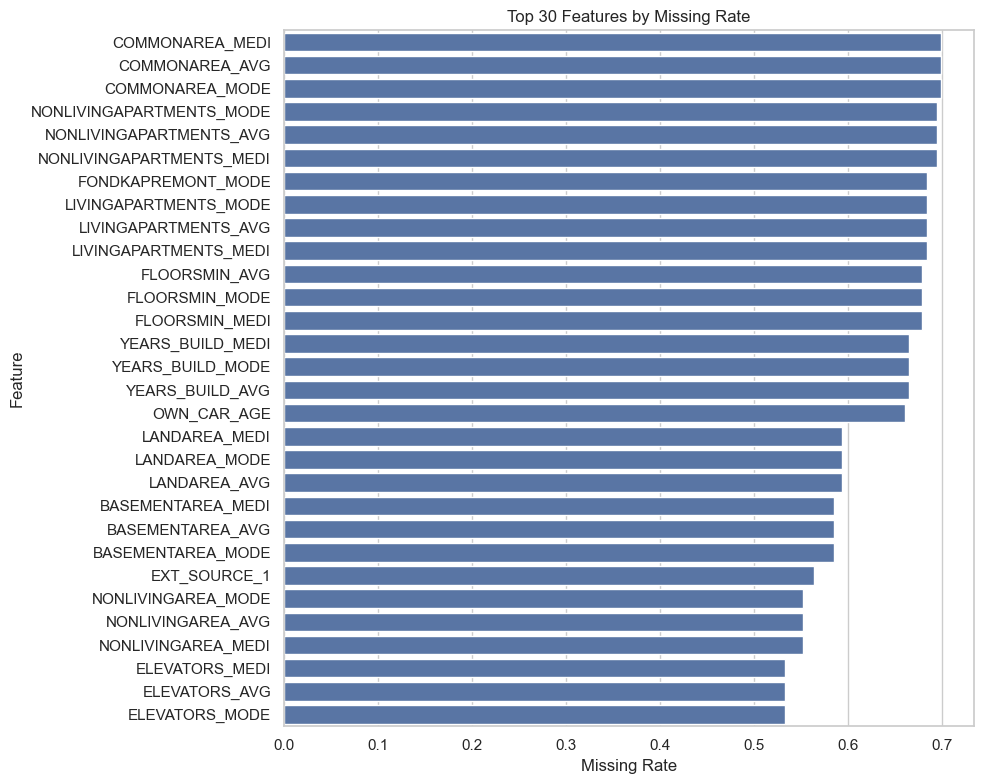

In [18]:
plt.figure(figsize=(10, 8))

top_missing = missing_values.head(30)

sns.barplot(
    data=top_missing,
    x="missing_rate",
    y="feature",
)

plt.title("Top 30 Features by Missing Rate")
plt.xlabel("Missing Rate")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [19]:
high_missing_features = missing_values[missing_values["missing_rate"] > 0.5]

high_missing_features

,feature,missing_rate,missing_count
0,COMMONAREA_MEDI,0.698723,214865
1,COMMONAREA_AVG,0.698723,214865
2,COMMONAREA_MODE,0.698723,214865
3,NONLIVINGAPARTMENTS_MODE,0.694330,213514
4,NONLIVINGAPARTMENTS_AVG,0.694330,213514
5,NONLIVINGAPARTMENTS_MEDI,0.694330,213514
6,FONDKAPREMONT_MODE,0.683862,210295
7,LIVINGAPARTMENTS_MODE,0.683550,210199
8,LIVINGAPARTMENTS_AVG,0.683550,210199
9,LIVINGAPARTMENTS_MEDI,0.683550,210199


In [20]:
len(high_missing_features)

41

### Missing values observations

В `application_train` есть 41 признак с долей пропусков выше 50%.

Большинство таких признаков связано с характеристиками жилья:

- площадь дома / квартиры;
- количество этажей;
- общая площадь;
- жилые и нежилые помещения;
- материал стен;
- тип дома;
- аварийное состояние дома.

На этом этапе мы не удаляем эти признаки автоматически.

Для дальнейшего моделирования возможны разные стратегии:

- оставить пропуски как есть для LightGBM;
- удалить признаки с очень высокой долей пропусков для простого baseline;
- заполнить числовые признаки медианой;
- добавить missing-indicator;
- обработать пропуски как отдельную категорию в WOE/scorecard.

## 5. Numeric features summary

Посмотрим базовую статистику по числовым признакам.

Нас интересуют:

- среднее значение;
- стандартное отклонение;
- минимумы и максимумы;
- количество уникальных значений;
- доля пропусков.

Это поможет найти выбросы, бинарные флаги и признаки с необычными значениями.

In [21]:
numeric_summary = application_train[numeric_features].describe().T

numeric_summary["missing_count"] = application_train[numeric_features].isna().sum()
numeric_summary["missing_rate"] = application_train[numeric_features].isna().mean()
numeric_summary["n_unique"] = application_train[numeric_features].nunique()

numeric_summary.head()

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate,n_unique
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0,0,0.0,307511
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0,0,0.0,2
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0,0,0.0,15
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0,0,0.0,2548
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0,0,0.0,5603


In [22]:
numeric_summary.sort_values("missing_rate", ascending=False).head(30)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate,n_unique
COMMONAREA_MODE,92646.0,0.042553,0.074445,0.000000,0.007200,0.019000,0.049000,1.000000,214865,0.698723,3128
COMMONAREA_AVG,92646.0,0.044621,0.076036,0.000000,0.007800,0.021100,0.051500,1.000000,214865,0.698723,3181
COMMONAREA_MEDI,92646.0,0.044595,0.076144,0.000000,0.007900,0.020800,0.051300,1.000000,214865,0.698723,3202
NONLIVINGAPARTMENTS_AVG,93997.0,0.008809,0.047732,0.000000,0.000000,0.000000,0.003900,1.000000,213514,0.694330,386
NONLIVINGAPARTMENTS_MODE,93997.0,0.008076,0.046276,0.000000,0.000000,0.000000,0.003900,1.000000,213514,0.694330,167
NONLIVINGAPARTMENTS_MEDI,93997.0,0.008651,0.047415,0.000000,0.000000,0.000000,0.003900,1.000000,213514,0.694330,214
LIVINGAPARTMENTS_MODE,97312.0,0.105645,0.097880,0.000000,0.054200,0.077100,0.131300,1.000000,210199,0.683550,736
LIVINGAPARTMENTS_AVG,97312.0,0.100775,0.092576,0.000000,0.050400,0.075600,0.121000,1.000000,210199,0.683550,1868
LIVINGAPARTMENTS_MEDI,97312.0,0.101954,0.093642,0.000000,0.051300,0.076100,0.123100,1.000000,210199,0.683550,1097
FLOORSMIN_MEDI,98869.0,0.231625,0.161934,0.000000,0.083300,0.208300,0.375000,1.000000,208642,0.678486,47


In [23]:
low_unique_numeric = (
    numeric_summary
    .sort_values("n_unique")
    .head(40)
)

low_unique_numeric[["min", "max", "mean", "n_unique", "missing_rate"]]

,min,max,mean,n_unique,missing_rate
REG_REGION_NOT_WORK_REGION,0.0,1.0,0.050769,2,0.000000
LIVE_REGION_NOT_WORK_REGION,0.0,1.0,0.040659,2,0.000000
REG_CITY_NOT_LIVE_CITY,0.0,1.0,0.078173,2,0.000000
REG_CITY_NOT_WORK_CITY,0.0,1.0,0.230454,2,0.000000
LIVE_CITY_NOT_WORK_CITY,0.0,1.0,0.179555,2,0.000000
FLAG_DOCUMENT_15,0.0,1.0,0.001210,2,0.000000
FLAG_DOCUMENT_14,0.0,1.0,0.002936,2,0.000000
FLAG_DOCUMENT_13,0.0,1.0,0.003525,2,0.000000
REG_REGION_NOT_LIVE_REGION,0.0,1.0,0.015144,2,0.000000
FLAG_DOCUMENT_12,0.0,1.0,0.000007,2,0.000000


### Numeric features observations

Числовые признаки включают разные группы:

- денежные признаки: `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`;
- временные признаки: `DAYS_BIRTH`, `DAYS_EMPLOYED`, `DAYS_REGISTRATION`;
- внешние скоринговые признаки: `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`;
- бинарные флаги: `FLAG_DOCUMENT_*`, `FLAG_PHONE`, `FLAG_EMAIL`;
- признаки жилья: `APARTMENTS_*`, `COMMONAREA_*`, `LIVINGAREA_*`.

Часть числовых признаков на самом деле является бинарными флагами, поэтому их не стоит анализировать как обычные непрерывные переменные.

## 6. Correlation with target

Посмотрим, какие числовые признаки сильнее всего связаны с `TARGET`.

Важно помнить:

- корреляция показывает только линейную связь;
- низкая корреляция не означает, что признак бесполезен;
- категориальные признаки здесь не учитываются;
- для кредитного скоринга позже лучше дополнительно смотреть IV / WOE и feature importance.

In [27]:
target_corr = (
    application_train[numeric_features]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
)

target_corr.head(30)

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                 -0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                 -0.044003
FLOORSMAX_MEDI                -0.043768
FLOORSMAX_MODE                -0.043226
DAYS_REGISTRATION              0.041975
AMT_GOODS_PRICE               -0.039645
OWN_CAR_AGE                    0.037612
REGION_POPULATION_RELATIVE    -0.037227
ELEVATORS_AVG                 -0.034199
ELEVATORS_MEDI                -0.033863
FLOORSMIN_AVG                 -0.033614
FLOORSMIN_MEDI                -0.033394
LIVINGAREA_AVG                -0.032997


In [25]:
target_corr_table = (
    target_corr
    .rename("correlation_with_target")
    .reset_index()
    .rename(columns={"index": "feature"})
)

target_corr_table.head(30)

,feature,correlation_with_target
0,EXT_SOURCE_3,-0.178919
1,EXT_SOURCE_2,-0.160472
2,EXT_SOURCE_1,-0.155317
3,DAYS_BIRTH,0.078239
4,REGION_RATING_CLIENT_W_CITY,0.060893
5,REGION_RATING_CLIENT,0.058899
6,DAYS_LAST_PHONE_CHANGE,0.055218
7,DAYS_ID_PUBLISH,0.051457
8,REG_CITY_NOT_WORK_CITY,0.050994
9,FLAG_EMP_PHONE,0.045982


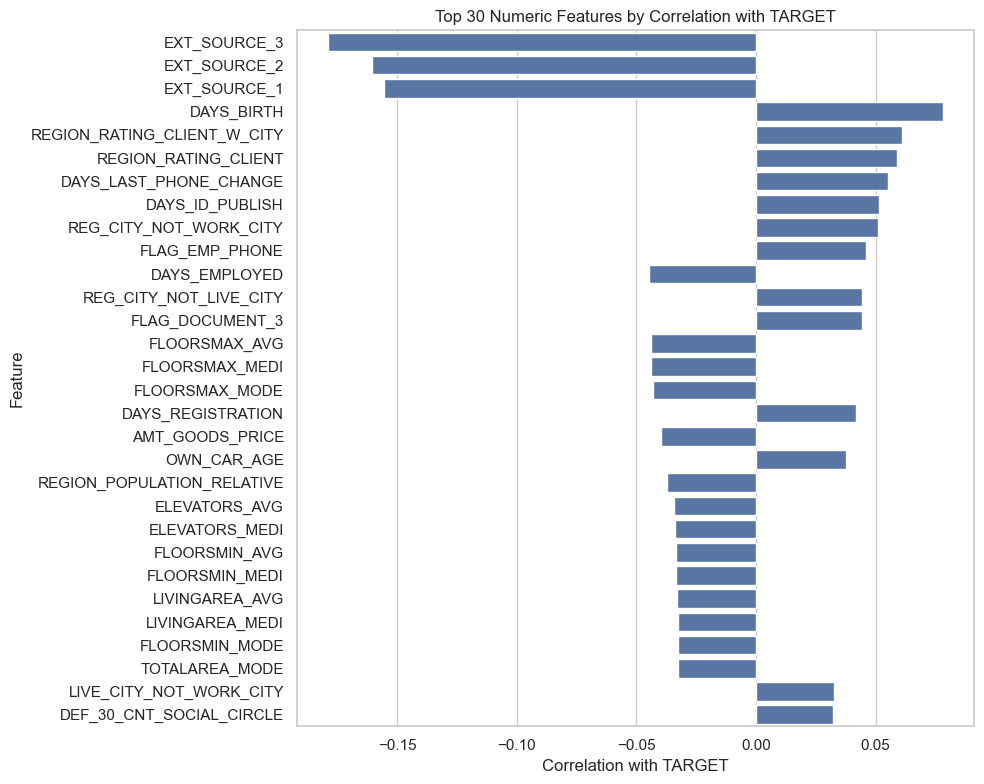

In [26]:
plt.figure(figsize=(10, 8))

top_corr = target_corr.head(30)

sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
)

plt.title("Top 30 Numeric Features by Correlation with TARGET")
plt.xlabel("Correlation with TARGET")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [28]:
target_corr_table.sort_values(
    "correlation_with_target",
    ascending=False,
).head(20)

,feature,correlation_with_target
3,DAYS_BIRTH,0.078239
4,REGION_RATING_CLIENT_W_CITY,0.060893
5,REGION_RATING_CLIENT,0.058899
6,DAYS_LAST_PHONE_CHANGE,0.055218
7,DAYS_ID_PUBLISH,0.051457
8,REG_CITY_NOT_WORK_CITY,0.050994
9,FLAG_EMP_PHONE,0.045982
11,REG_CITY_NOT_LIVE_CITY,0.044395
12,FLAG_DOCUMENT_3,0.044346
16,DAYS_REGISTRATION,0.041975


In [29]:
target_corr_table.sort_values(
    "correlation_with_target",
    ascending=True,
).head(20)

,feature,correlation_with_target
0,EXT_SOURCE_3,-0.178919
1,EXT_SOURCE_2,-0.160472
2,EXT_SOURCE_1,-0.155317
10,DAYS_EMPLOYED,-0.044932
13,FLOORSMAX_AVG,-0.044003
14,FLOORSMAX_MEDI,-0.043768
15,FLOORSMAX_MODE,-0.043226
17,AMT_GOODS_PRICE,-0.039645
19,REGION_POPULATION_RELATIVE,-0.037227
20,ELEVATORS_AVG,-0.034199


### Correlation observations

Самую заметную связь с `TARGET` показывают признаки `EXT_SOURCE_1`, `EXT_SOURCE_2` и `EXT_SOURCE_3`.

Их корреляция с `TARGET` отрицательная: чем выше значение внешнего скорингового признака, тем ниже вероятность дефолта.

Также заметна связь с возрастом клиента через `DAYS_BIRTH`. Так как `DAYS_BIRTH` хранится отрицательным числом, положительная корреляция означает, что более молодые клиенты чаще имеют `TARGET = 1`.

Региональные признаки `REGION_RATING_CLIENT` и `REGION_RATING_CLIENT_W_CITY` положительно связаны с дефолтом, что может означать более высокий риск для клиентов из регионов с худшим рейтингом.

Часть жилищных признаков также попадает в топ корреляций, но у них высокая доля пропусков, поэтому их нужно обрабатывать осторожно.

Корреляция является только первичной проверкой. Для финального отбора признаков позже нужно использовать IV / WOE, feature importance и SHAP.

## 7. External source features

Признаки `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` выглядят как внешние скоринговые оценки клиента.

На предыдущем графике они показали самую сильную отрицательную корреляцию с `TARGET`.

Проверим:

- базовую статистику;
- долю пропусков;
- корреляцию с `TARGET`;
- распределение значений отдельно для `TARGET = 0` и `TARGET = 1`.

In [30]:
ext_source_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

application_train[ext_source_features + ["TARGET"]].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,0.855000
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,0.896010
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000


In [31]:
ext_source_missing = pd.DataFrame(
    {
        "missing_count": application_train[ext_source_features].isna().sum(),
        "missing_rate": application_train[ext_source_features].isna().mean(),
    }
).sort_values("missing_rate", ascending=False)

ext_source_missing

,missing_count,missing_rate
EXT_SOURCE_1,173378,0.563811
EXT_SOURCE_3,60965,0.198253
EXT_SOURCE_2,660,0.002146


In [32]:
application_train.groupby("TARGET")[ext_source_features].mean()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,,,
0,0.511461,0.523479,0.520969
1,0.386968,0.410935,0.390717


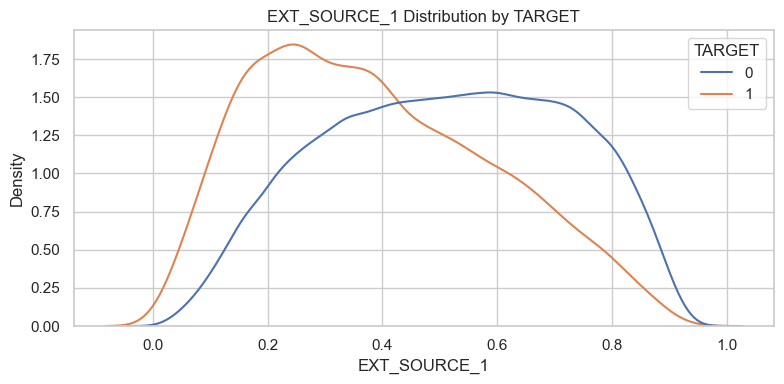

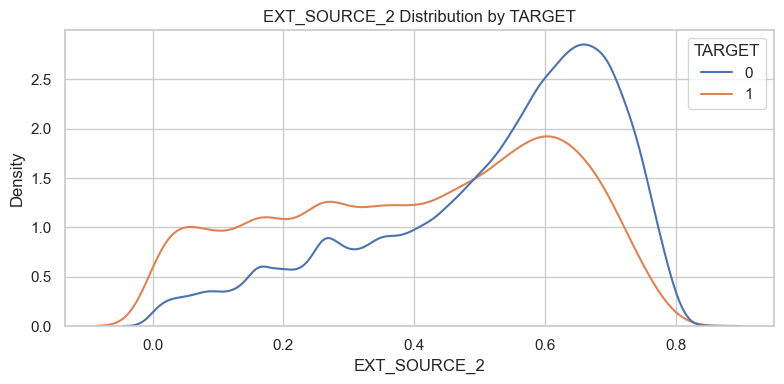

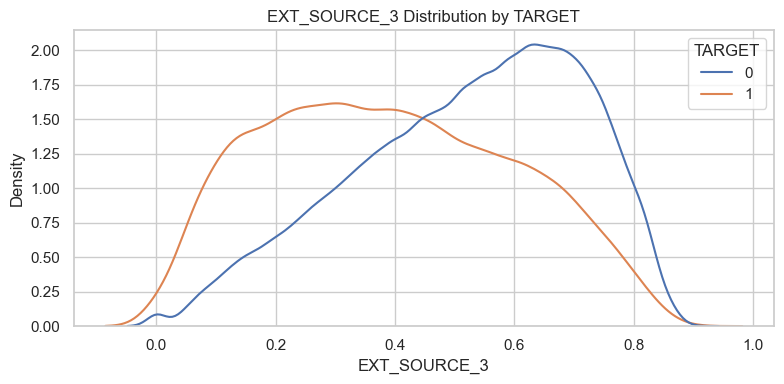

In [33]:
for col in ext_source_features:
    plt.figure(figsize=(8, 4))

    sns.kdeplot(
        data=application_train,
        x=col,
        hue="TARGET",
        common_norm=False,
    )

    plt.title(f"{col} Distribution by TARGET")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

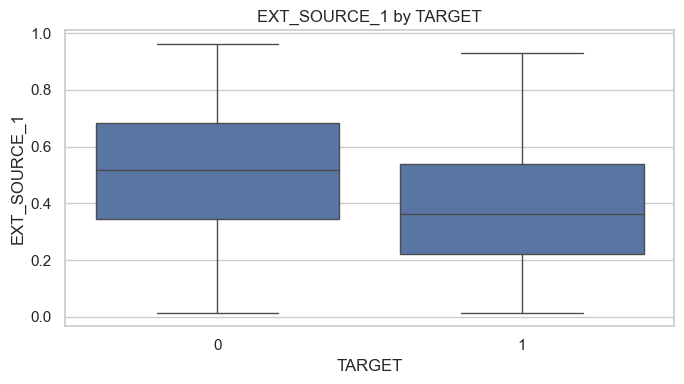

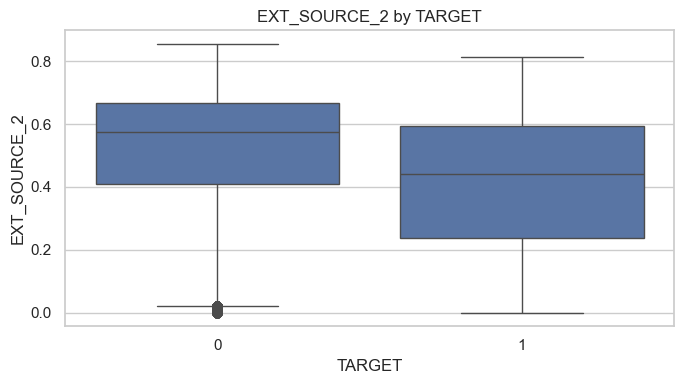

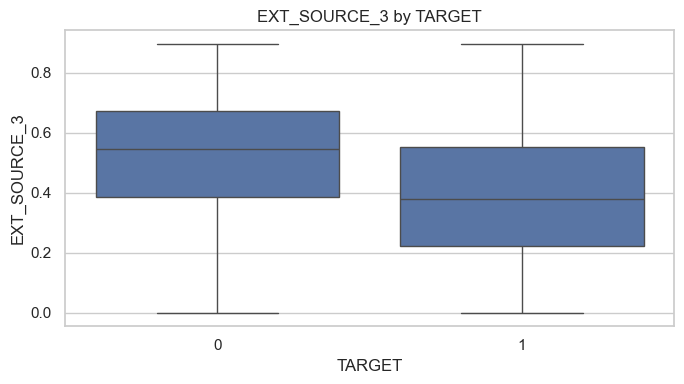

In [34]:
for col in ext_source_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=application_train,
        x="TARGET",
        y=col,
    )

    plt.title(f"{col} by TARGET")
    plt.xlabel("TARGET")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()